# Análisis de Telemetría de UAVs: Comparación de Variabilidad y Estabilidad Física (Real vs. Simulado)

## Introducción y Objetivos
Este notebook presenta un análisis comparativo de la telemetría de vuelos de drones reales frente a vuelos simulados en AirSim. El objetivo principal es evaluar y comparar la variabilidad de las maniobras, especialmente durante los cambios de dirección (giros), donde ocurren fenómenos de balance (oscilaciones en roll y pitch) debido a la inercia y los factores climáticos.

### Contexto de los Datos:
1. **Datos Reales (`actual_telemetry/UAV_telemetry_dataset/consolidated_telemetry.csv`):** Contiene la telemetría consolidada de dos vuelos reales (`drone1` y `drone2`). Registra coordenadas GPS (latitud, longitud, altitud), rumbo de la aeronave (`headingDroneDegress`) y orientación del gimbal.
2. **Datos Simulados (`simulated_telemetry/flights/20260413/telemetry_*.csv`):** 100 archivos de vuelos simulados que siguen una ruta de calibración predefinida en AirSim. Registra posiciones locales ($x, y, z$ en coordenadas NED), velocidades ($v_x, v_y, v_z$) y rumbo (`yaw_deg`).

### Enfoque Físico:
Dado que la telemetría simulada no contiene directamente los ángulos de roll y pitch del dron, y la telemetría real solo contiene las posiciones y el rumbo, estimaremos el roll ($\phi$) y el pitch ($\theta$) físico del dron utilizando los principios de la dinámica de cuadricópteros:
- Un dron acelera horizontalmente inclinando su vector de empuje.
- Por tanto, la aceleración en el marco de referencia del cuerpo del dron (Body Frame) está directamente relacionada con los ángulos de roll y pitch:
  $$\theta \approx \arctan(-a_{bf} / g)$$
  $$\phi \approx \arctan(a_{bl} / g)$$
donde $a_{bf}$ es la aceleración hacia adelante, $a_{bl}$ la aceleración lateral derecha, y $g = 9.81\text{ m/s}^2$ es la gravedad.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy import stats
from scipy.signal import savgol_filter

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14


## 1. Definición de Funciones de Procesamiento y Estimación

Definiremos las funciones para:
- Convertir coordenadas GPS reales a coordenadas cartesianas planas locales (en metros).
- Calcular derivadas numéricas suavizadas de posición para obtener velocidad y aceleración (reduciendo el ruido del GPS).
- Estimar roll y pitch mediante la rotación de las aceleraciones al marco del cuerpo (Body Frame) y la aplicación de las ecuaciones dinámicas.


In [2]:
def latlon_to_local(df, lat_col='aircraftLatitude', lon_col='aircraftLongitude'):
    """Convierte coordenadas geográficas a metros locales usando proyección plana."""
    df = df.dropna(subset=[lat_col, lon_col]).copy()
    R = 6371000.0  # Radio de la Tierra en metros
    lat0 = df[lat_col].mean()
    lon0 = df[lon_col].mean()
    lat0_rad = np.radians(lat0)
    
    lat_rad = np.radians(df[lat_col])
    lon_rad = np.radians(df[lon_col])
    
    df['x_local'] = R * (lon_rad - np.radians(lon0)) * np.cos(lat0_rad)
    df['y_local'] = R * (lat_rad - np.radians(lat0))
    return df

def estimate_attitude(df, g=9.81):
    """Estima roll y pitch en base a aceleraciones en el marco del cuerpo (Body Frame)."""
    psi = df['heading']
    a_N = df['a_North']
    a_E = df['a_East']
    
    # Rotación de aceleración global a marco del dron (Body Frame)
    # Forward acceleration
    a_bf = a_N * np.cos(psi) + a_E * np.sin(psi)
    # Lateral (right) acceleration
    a_bl = -a_N * np.sin(psi) + a_E * np.cos(psi)
    
    df['a_forward'] = a_bf
    df['a_lateral'] = a_bl
    
    # Estimación de inclinaciones en grados
    df['est_pitch'] = -np.arctan2(a_bf, g) * 180.0 / np.pi
    df['est_roll'] = np.arctan2(a_bl, g) * 180.0 / np.pi
    return df

def process_real_drone(df):
    """Preprocesa la telemetría real: suavizado, cálculo de velocidad/aceleración y actitud."""
    df = latlon_to_local(df)
    
    # Mapeo de coordenadas (North = Y_local, East = X_local)
    df['North'] = df['y_local']
    df['East'] = df['x_local']
    df['Altitude'] = df['aircraftAltitude']
    
    # Ordenar y crear columna de tiempo en segundos
    df = df.sort_values(by='timestamp_ms').reset_index(drop=True)
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    
    # Eliminar duplicados temporales
    df['dt'] = df['time_s'].diff()
    df = df[df['dt'].isna() | (df['dt'] > 0)].reset_index(drop=True)
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0
    
    # Suavizado triple para amortiguar ruido de GPS en derivadas sucesivas
    n = len(df)
    window = min(15, n - (1 if n % 2 == 0 else 2))
    
    if window >= 5:
        df['N_smooth'] = savgol_filter(df['North'], window, 2)
        df['E_smooth'] = savgol_filter(df['East'], window, 2)
    else:
        df['N_smooth'] = df['North']
        df['E_smooth'] = df['East']
        
    df['v_North'] = np.gradient(df['N_smooth'], df['time_s'])
    df['v_East'] = np.gradient(df['E_smooth'], df['time_s'])
    
    if window >= 5:
        df['v_North'] = savgol_filter(df['v_North'], window, 2)
        df['v_East'] = savgol_filter(df['v_East'], window, 2)
        
    df['a_North'] = np.gradient(df['v_North'], df['time_s'])
    df['a_East'] = np.gradient(df['v_East'], df['time_s'])
    
    if window >= 5:
        df['a_North'] = savgol_filter(df['a_North'], window, 2)
        df['a_East'] = savgol_filter(df['a_East'], window, 2)
        
    # Rumbo en radianes (heading de 0 a 360 grados)
    df['heading'] = np.radians(df['headingDroneDegress'])
    
    df = estimate_attitude(df)
    
    # Tasa de giro (yaw rate)
    unwrapped = np.unwrap(df['heading'])
    df['yaw_rate'] = np.gradient(unwrapped, df['time_s'])
    df['yaw_rate_deg'] = np.degrees(df['yaw_rate'])
    
    return df

def process_simulated_file(filepath):
    """Preprocesa un archivo de telemetría simulada."""
    df = pd.read_csv(filepath)
    
    df['North'] = df['x']
    df['East'] = df['y']
    df['Altitude'] = -df['z']
    df['time_s'] = df['sim_t'] - df['sim_t'].iloc[0]
    
    # Calcular aceleraciones a partir de vx, vy provistas por AirSim
    df['a_North'] = np.gradient(df['vx'], df['time_s'])
    df['a_East'] = np.gradient(df['vy'], df['time_s'])
    
    # Suavizado leve para las aceleraciones
    n = len(df)
    window = min(11, n - (1 if n % 2 == 0 else 2))
    if window >= 5:
        df['a_North'] = savgol_filter(df['a_North'], window, 2)
        df['a_East'] = savgol_filter(df['a_East'], window, 2)
        
    df['heading'] = np.radians(df['yaw_deg'])
    
    df = estimate_attitude(df)
    
    unwrapped = np.unwrap(df['heading'])
    df['yaw_rate'] = np.gradient(unwrapped, df['time_s'])
    df['yaw_rate_deg'] = np.degrees(df['yaw_rate'])
    
    return df


## 2. Carga y Procesamiento de los Conjuntos de Datos

Cargaremos los datos reales (`consolidated_telemetry.csv`) para `drone1` y `drone2`. 
Asimismo, cargaremos y procesaremos de forma masiva los 100 archivos de telemetría simulada para obtener estadísticas agregadas representativas de la simulación.


In [3]:
# Carga de datos reales
real_path = os.path.join('actual_telemetry', 'consolidated_telemetry.csv')
df_real_raw = pd.read_csv(real_path)

df_d1 = df_real_raw[df_real_raw['droneID'] == 'drone1'].copy()
df_d2 = df_real_raw[df_real_raw['droneID'] == 'drone2'].copy()

print("Procesando telemetría real...")
df_d1_proc = process_real_drone(df_d1)
df_d2_proc = process_real_drone(df_d2)
print(f"Dron 1 (Real) - Filas procesadas: {df_d1_proc.shape[0]}")
print(f"Dron 2 (Real) - Filas procesadas: {df_d2_proc.shape[0]}")

# Carga de datos simulados
sim_files = sorted(glob.glob('simulated_telemetry/flights/20260413/telemetry_*.csv'))
print(f"\nCargando y procesando {len(sim_files)} archivos de telemetría simulada...")

sim_dfs = []
for i, f in enumerate(sim_files):
    try:
        df_sim = process_simulated_file(f)
        df_sim['flight_id'] = f"sim_{i+1}"
        sim_dfs.append(df_sim)
    except Exception as e:
        print(f"Error procesando {f}: {e}")

df_sim_all = pd.concat(sim_dfs, ignore_index=True)
print(f"Total registros simulados consolidados: {df_sim_all.shape[0]}")


Procesando telemetría real...
Dron 1 (Real) - Filas procesadas: 329
Dron 2 (Real) - Filas procesadas: 456

Cargando y procesando 100 archivos de telemetría simulada...
Total registros simulados consolidados: 79304


## 3. Segmentación de Vuelo: Rectas vs. Giros (Maniobras de Rumbo)

Para aislar el efecto de la inercia durante los cambios de dirección, calculamos la tasa de giro absoluta en grados por segundo (`abs_yaw_rate_deg`). 
Clasificamos los instantes en:
- **Giro (Turn):** Tasa de giro $> 5.0$ grados/segundo.
- **Recta (Straight):** Tasa de giro $\le 5.0$ grados/segundo.


In [4]:
threshold = 5.0  # umbral en deg/s

# Dron 1 Real
df_d1_proc['maneuver'] = np.where(df_d1_proc['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')
# Dron 2 Real
df_d2_proc['maneuver'] = np.where(df_d2_proc['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')
# Simulados
df_sim_all['maneuver'] = np.where(df_sim_all['yaw_rate_deg'].abs() > threshold, 'Giro', 'Recta')

print("Distribución de maniobras:")
print("Real Dron 1:\n", df_d1_proc['maneuver'].value_counts())
print("\nReal Dron 2:\n", df_d2_proc['maneuver'].value_counts())
print("\nSimulados Consolidados:\n", df_sim_all['maneuver'].value_counts())


Distribución de maniobras:
Real Dron 1:
 maneuver
Recta    312
Giro      17
Name: count, dtype: int64

Real Dron 2:
 maneuver
Recta    427
Giro      29
Name: count, dtype: int64

Simulados Consolidados:
 maneuver
Recta    75291
Giro      4013
Name: count, dtype: int64


Nota: en la telemetría simulada no existen columnas gimbal_*; se usa el promedio por vuelo de la orientación estimada como proxy.


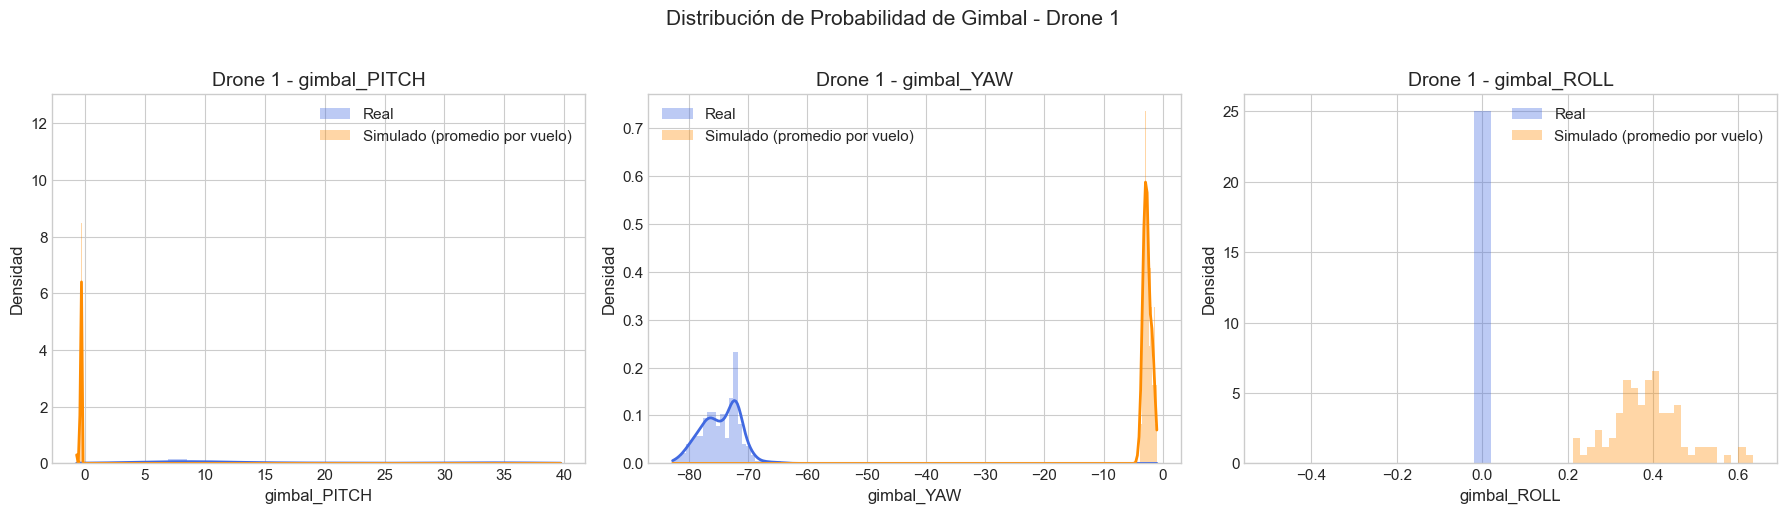

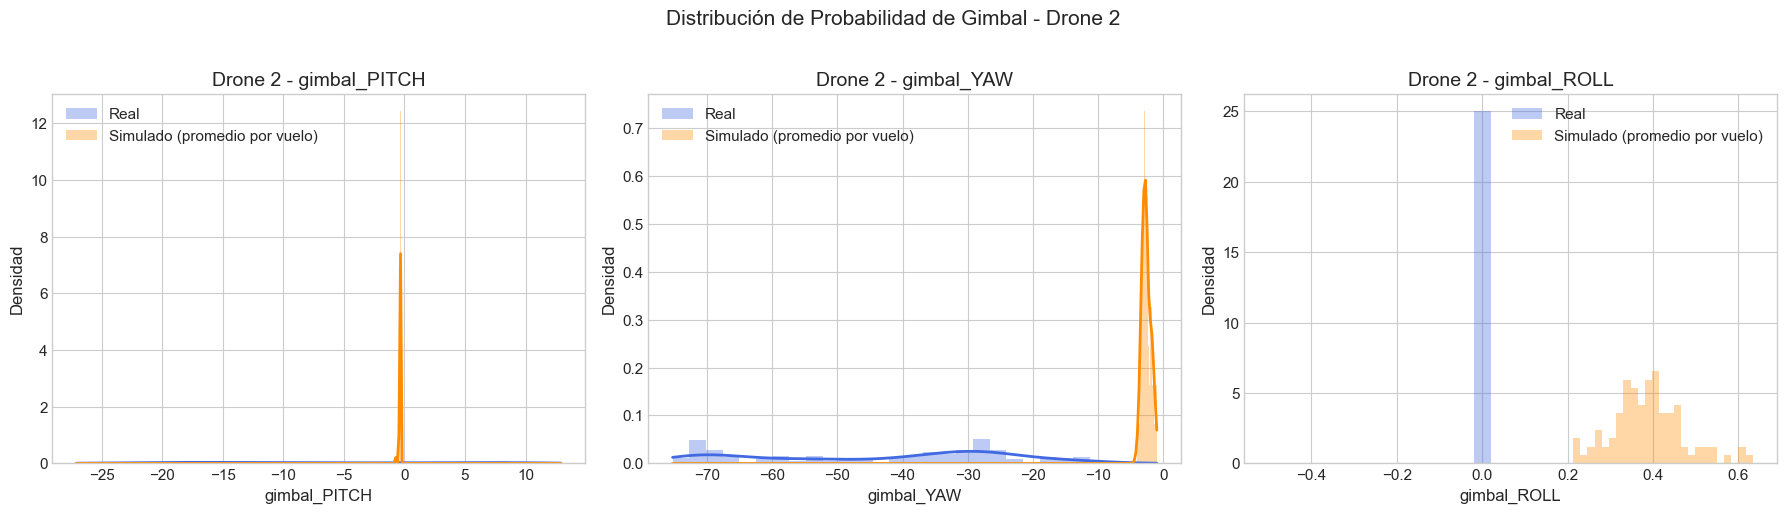

In [5]:
# Distribuciones de probabilidad de gimbal: real vs. simulación (promedio por vuelo)

def _plot_dist(ax, real_values, sim_values, title, xlabel):
    real_values = pd.Series(real_values).dropna().astype(float)
    sim_values = pd.Series(sim_values).dropna().astype(float)

    ax.hist(real_values, bins=25, density=True, alpha=0.35, color='royalblue', label='Real')
    ax.hist(sim_values, bins=25, density=True, alpha=0.35, color='darkorange', label='Simulado (promedio por vuelo)')

    combined = pd.concat([real_values, sim_values], ignore_index=True)
    if len(combined) > 2 and combined.nunique() > 1:
        x_min, x_max = combined.min(), combined.max()
        x = np.linspace(x_min, x_max, 300)
        try:
            kde_real = stats.gaussian_kde(real_values)
            kde_sim = stats.gaussian_kde(sim_values)
            ax.plot(x, kde_real(x), color='royalblue', lw=2)
            ax.plot(x, kde_sim(x), color='darkorange', lw=2)
        except Exception:
            pass

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True)

# Simulado: promedio por vuelo usando la actitud estimada como proxy de orientación
df_sim_proxy = (
    df_sim_all.groupby('flight_id', as_index=False)
    .agg({
        'est_pitch': 'mean',
        'est_roll': 'mean',
        'yaw_deg': 'mean'
    })
    .rename(columns={
        'est_pitch': 'gimbal_PITCH',
        'est_roll': 'gimbal_ROLL',
        'yaw_deg': 'gimbal_YAW'
    })
)

print("Nota: en la telemetría simulada no existen columnas gimbal_*; se usa el promedio por vuelo de la orientación estimada como proxy.")

for drone_name, df_real in [('Drone 1', df_d1_proc), ('Drone 2', df_d2_proc)]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    _plot_dist(
        axes[0],
        df_real['gimbal_PITCH'],
        df_sim_proxy['gimbal_PITCH'],
        f'{drone_name} - gimbal_PITCH',
        'gimbal_PITCH'
    )
    _plot_dist(
        axes[1],
        df_real['gimbal_YAW'],
        df_sim_proxy['gimbal_YAW'],
        f'{drone_name} - gimbal_YAW',
        'gimbal_YAW'
    )
    _plot_dist(
        axes[2],
        df_real['gimbal_ROLL'],
        df_sim_proxy['gimbal_ROLL'],
        f'{drone_name} - gimbal_ROLL',
        'gimbal_ROLL'
    )
    
    fig.suptitle(f'Distribución de Probabilidad de Gimbal - {drone_name}', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Visualización de Trayectorias y Dinámica de Vuelo

Primero, visualizamos las trayectorias 2D de los drones para comprender el patrón de vuelo. El vuelo real sigue una trayectoria rectangular limpia, mientras que la simulación sigue una trayectoria en forma de mariposa/cruz con giros más agudos en el centro y las esquinas.


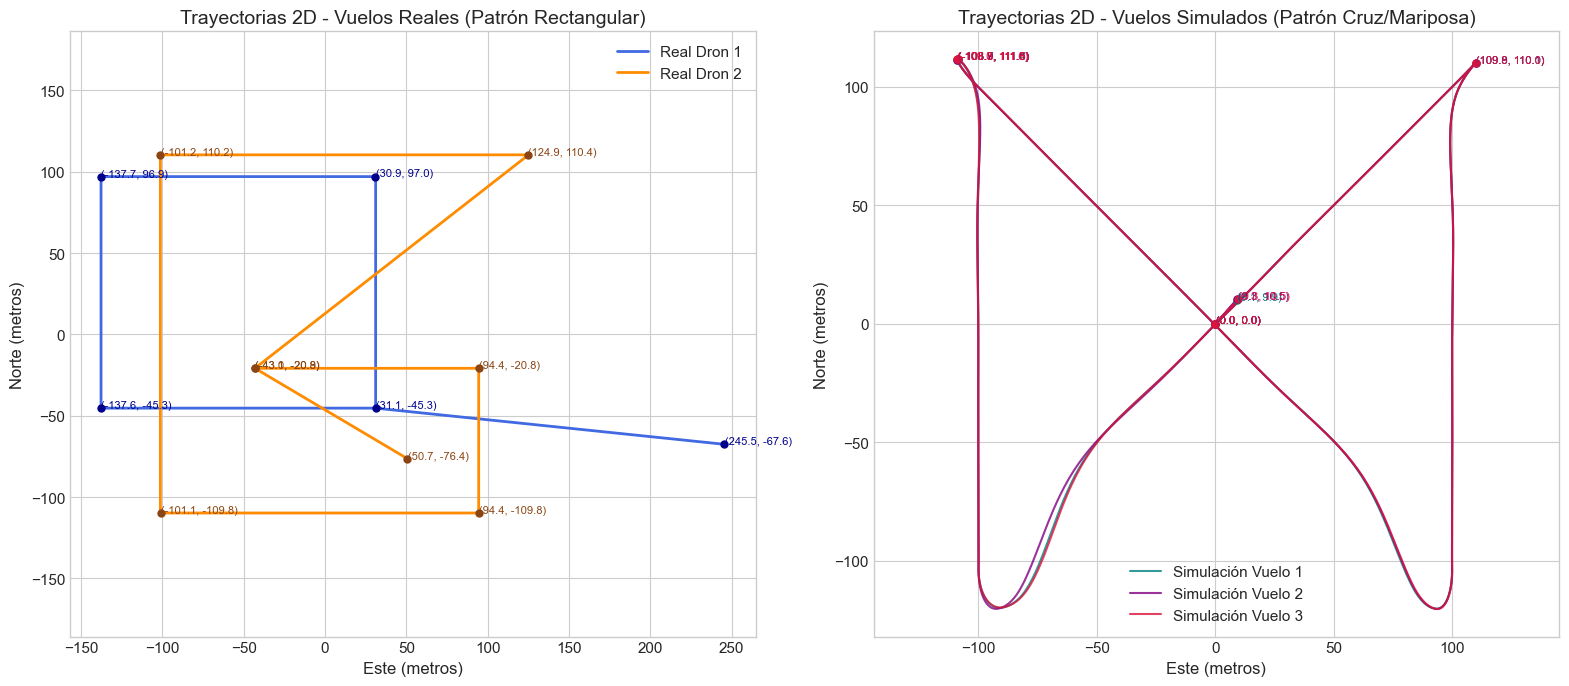

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función para detectar puntos de giro basados en cambios significativos en la dirección del movimiento
def get_turn_indices(df, x_col='East', y_col='North', min_dist=0.2, dot_threshold=0.95):
    significant_points = [0] # Always include the start point
    last_idx = 0
    last_vector = None
    
    for i in range(1, len(df)):
        dx = df[x_col].iloc[i] - df[x_col].iloc[last_idx]
        dy = df[y_col].iloc[i] - df[y_col].iloc[last_idx]
        dist = np.sqrt(dx**2 + dy**2)
        
        # Procesar solo si se ha movido una distancia mínima (para evitar ruido de hover)
        if dist > min_dist:
            curr_vector = np.array([dx/dist, dy/dist])
            if last_vector is not None:
                # Chquear producto punto para detectar cambio de dirección
                if np.dot(curr_vector, last_vector) < dot_threshold:
                    significant_points.append(last_idx)
            last_vector = curr_vector
            last_idx = i
            
    # Incluir siempre el punto final
    if len(df) - 1 not in significant_points:
        significant_points.append(len(df) - 1)
        
    return significant_points

# Función para dibujar los puntos de giro detectados y sus coordenadas
def plot_turn_coordinates(ax, df, color):
    turn_indices = get_turn_indices(df, 'East', 'North')
    for i in turn_indices:
        x, y = df['East'].iloc[i], df['North'].iloc[i]
        ax.plot(x, y, marker='o', color=color, markersize=5, zorder=4)
        # Offset the text slightly so it doesn't overlap perfectly with the dot
        ax.text(x + 0.1, y + 0.1, f'({x:.1f}, {y:.1f})', fontsize=8, color=color, zorder=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Vuelo Real (Dron 1 y Dron 2)
ax1.plot(df_d1_proc['East'], df_d1_proc['North'], label='Real Dron 1', color='royalblue', lw=2)
ax1.plot(df_d2_proc['East'], df_d2_proc['North'], label='Real Dron 2', color='darkorange', lw=2)

# Dibuja los puntos de giro detectados y sus coordenadas para los vuelos reales
plot_turn_coordinates(ax1, df_d1_proc, 'darkblue')
plot_turn_coordinates(ax1, df_d2_proc, 'saddlebrown')

ax1.set_xlabel('Este (metros)')
ax1.set_ylabel('Norte (metros)')
ax1.set_title('Trayectorias 2D - Vuelos Reales (Patrón Rectangular)')
ax1.legend()
ax1.grid(True)
ax1.axis('equal')


# Gráfico 2: Vuelo Simulado (Muestra representativa de los primeros 3 archivos)
colors = ['teal', 'purple', 'crimson']
for i in range(3):
    sub_sim = df_sim_all[df_sim_all['flight_id'] == f"sim_{i+1}"]
    ax2.plot(sub_sim['East'], sub_sim['North'], label=f'Simulación Vuelo {i+1}', color=colors[i], alpha=0.8)
    
    # Dibuja los puntos de giro detectados y sus coordenadas para los vuelos simulados
    plot_turn_coordinates(ax2, sub_sim, colors[i])

ax2.set_xlabel('Este (metros)')
ax2.set_ylabel('Norte (metros)')
ax2.set_title('Trayectorias 2D - Vuelos Simulados (Patrón Cruz/Mariposa)')
ax2.legend()
ax2.grid(True)
ax2.axis('equal')

plt.tight_layout()
plt.show()


## 5. Visualización del Fenómeno de Balance (Roll y Pitch durante los Giros)

Veamos cómo se comportan los ángulos estimados de Roll y Pitch cuando el dron experimenta giros (tasa de giro elevada). Graficaremos una serie de tiempo típica de un vuelo real y un vuelo simulado.


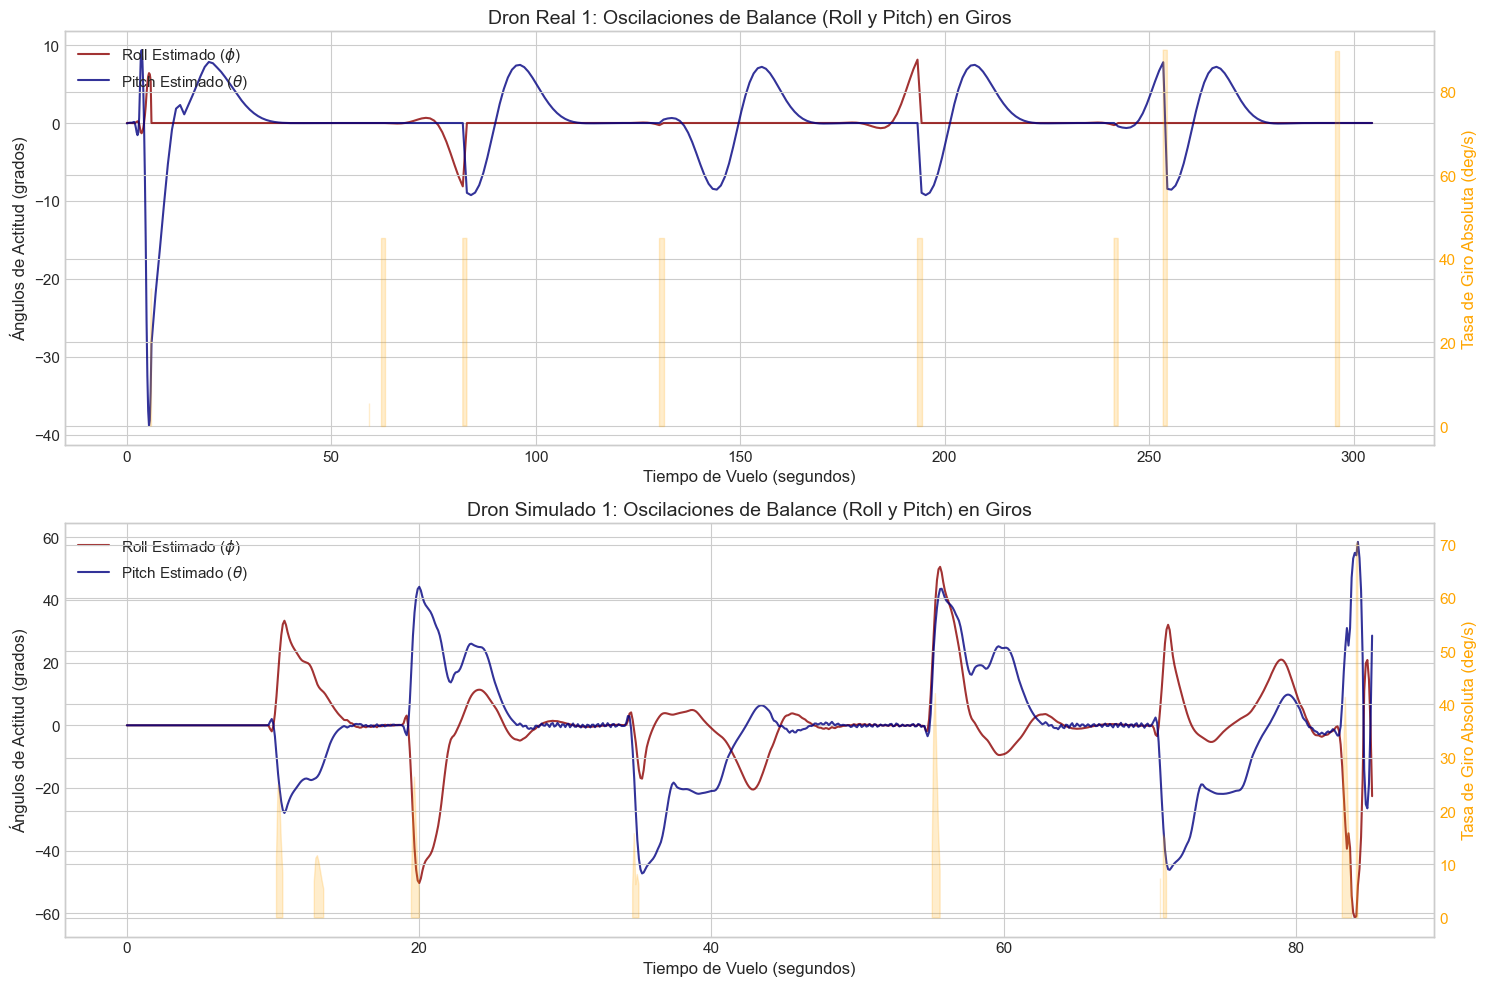

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Dron Real 1
ax1.plot(df_d1_proc['time_s'], df_d1_proc['est_roll'], label='Roll Estimado ($\\phi$)', color='darkred', alpha=0.8)
ax1.plot(df_d1_proc['time_s'], df_d1_proc['est_pitch'], label='Pitch Estimado ($\\theta$)', color='navy', alpha=0.8)
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df_d1_proc['time_s'], 0, df_d1_proc['yaw_rate_deg'].abs(), 
                      where=(df_d1_proc['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax1_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')
ax1.set_ylabel('Ángulos de Actitud (grados)')
ax1.set_xlabel('Tiempo de Vuelo (segundos)')
ax1.set_title('Dron Real 1: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax1.legend(loc='upper left')

# Dron Simulado (Vuelo 1)
df_sim_v1 = df_sim_all[df_sim_all['flight_id'] == 'sim_1'].copy()
ax2.plot(df_sim_v1['time_s'], df_sim_v1['est_roll'], label='Roll Estimado ($\\phi$)', color='darkred', alpha=0.8)
ax2.plot(df_sim_v1['time_s'], df_sim_v1['est_pitch'], label='Pitch Estimado ($\\theta$)', color='navy', alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.fill_between(df_sim_v1['time_s'], 0, df_sim_v1['yaw_rate_deg'].abs(), 
                      where=(df_sim_v1['maneuver'] == 'Giro'), color='orange', alpha=0.2, label='Fase de Giro')
ax2_twin.set_ylabel('Tasa de Giro Absoluta (deg/s)', color='orange')
ax2_twin.tick_params(axis='y', labelcolor='orange')
ax2.set_ylabel('Ángulos de Actitud (grados)')
ax2.set_xlabel('Tiempo de Vuelo (segundos)')
ax2.set_title('Dron Simulado 1: Oscilaciones de Balance (Roll y Pitch) en Giros')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


Analisis del cambio de velocidad en los tres ejes

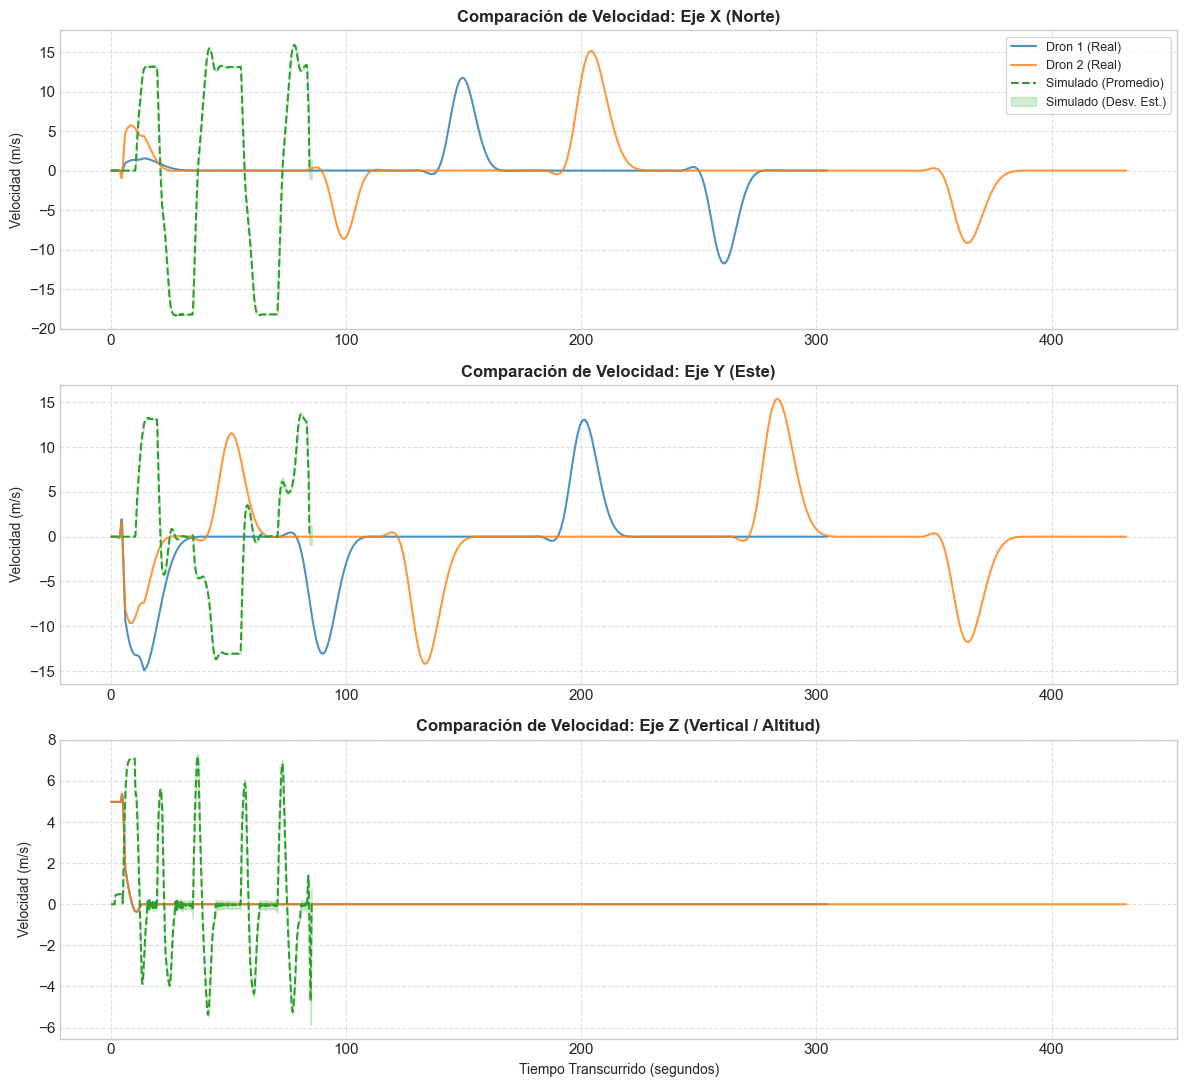

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Estimar y suavizar la velocidad vertical (Z / Altitud) para los drones reales
for df in [df_d1_proc, df_d2_proc]:
    df['v_Altitude'] = np.gradient(df['Altitude'], df['time_s'])
    n = len(df)
    window = min(15, n - (1 if n % 2 == 0 else 2))
    if window >= 5:
        df['v_Altitude'] = savgol_filter(df['v_Altitude'], window, 2)

# 2. Interpolar la telemetría simulada a un grid de tiempo común (0 a t_max)
t_sim_max = df_sim_all['time_s'].max()
t_common = np.linspace(0, t_sim_max, 500)

sim_vx_list = []
sim_vy_list = []
sim_vz_list = []

for flight_id, group in df_sim_all.groupby('flight_id'):
    # Interpolar vx (Norte), vy (Este) y -vz (Altitud / Ascendente)
    sim_vx_list.append(np.interp(t_common, group['time_s'], group['vx']))
    sim_vy_list.append(np.interp(t_common, group['time_s'], group['vy']))
    sim_vz_list.append(np.interp(t_common, group['time_s'], -group['vz']))

# Calcular promedios y desviaciones estándar de la simulación
mean_vx = np.mean(sim_vx_list, axis=0)
std_vx = np.std(sim_vx_list, axis=0)

mean_vy = np.mean(sim_vy_list, axis=0)
std_vy = np.std(sim_vy_list, axis=0)

mean_vz = np.mean(sim_vz_list, axis=0)
std_vz = np.std(sim_vz_list, axis=0)

# Paleta de colores consistente
colors = {'drone1': '#1f77b4', 'drone2': '#ff7f0e', 'simulated': '#2ca02c'}

# 3. Crear figura con 3 subplots para cada eje de velocidad
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

# --- Subplot 1: Eje X (Velocidad Norte) ---
axes[0].plot(df_d1_proc['time_s'], df_d1_proc['v_North'], label='Dron 1 (Real)', color=colors['drone1'], alpha=0.8)
axes[0].plot(df_d2_proc['time_s'], df_d2_proc['v_North'], label='Dron 2 (Real)', color=colors['drone2'], alpha=0.8)
axes[0].plot(t_common, mean_vx, label='Simulado (Promedio)', color=colors['simulated'], linestyle='--')
axes[0].fill_between(t_common, mean_vx - std_vx, mean_vx + std_vx, color=colors['simulated'], alpha=0.2, label='Simulado (Desv. Est.)')
axes[0].set_title('Comparación de Velocidad: Eje X (Norte)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Velocidad (m/s)', fontsize=10)
axes[0].legend(loc='upper right', frameon=True, fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 2: Eje Y (Velocidad Este) ---
axes[1].plot(df_d1_proc['time_s'], df_d1_proc['v_East'], label='Dron 1 (Real)', color=colors['drone1'], alpha=0.8)
axes[1].plot(df_d2_proc['time_s'], df_d2_proc['v_East'], label='Dron 2 (Real)', color=colors['drone2'], alpha=0.8)
axes[1].plot(t_common, mean_vy, label='Simulado (Promedio)', color=colors['simulated'], linestyle='--')
axes[1].fill_between(t_common, mean_vy - std_vy, mean_vy + std_vy, color=colors['simulated'], alpha=0.2)
axes[1].set_title('Comparación de Velocidad: Eje Y (Este)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Velocidad (m/s)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 3: Eje Z (Velocidad Vertical/Altitud) ---
axes[2].plot(df_d1_proc['time_s'], df_d1_proc['v_Altitude'], label='Dron 1 (Real)', color=colors['drone1'], alpha=0.8)
axes[2].plot(df_d2_proc['time_s'], df_d2_proc['v_Altitude'], label='Dron 2 (Real)', color=colors['drone2'], alpha=0.8)
axes[2].plot(t_common, mean_vz, label='Simulado (Promedio)', color=colors['simulated'], linestyle='--')
axes[2].fill_between(t_common, mean_vz - std_vz, mean_vz + std_vz, color=colors['simulated'], alpha=0.2)
axes[2].set_title('Comparación de Velocidad: Eje Z (Vertical / Altitud)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tiempo Transcurrido (segundos)', fontsize=10)
axes[2].set_ylabel('Velocidad (m/s)', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 6. Análisis Estadístico de la Variabilidad

Ahora analizaremos cuantitativamente la variabilidad (varianza y desviación estándar) de la dinámica del dron durante las maniobras de giro y vuelo recto.
Compararemos:
- Rumbo y tasa de cambio de rumbo (yaw rate).
- Roll estimado.
- Pitch estimado.


In [10]:
# Resumen de varianza agrupado por tipo de maniobra y origen del dato
summary = []

for dataset_name, df_sub in [('Real Dron 1', df_d1_proc), ('Real Dron 2', df_d2_proc), ('Simulado', df_sim_all)]:
    for maneuver in ['Recta', 'Giro']:
        df_m = df_sub[df_sub['maneuver'] == maneuver]
        summary.append({
            'Origen': dataset_name,
            'Maniobra': maneuver,
            'N_muestras': len(df_m),
            'YawRate_Var': df_m['yaw_rate_deg'].var(),
            'YawRate_Std': df_m['yaw_rate_deg'].std(),
            'Roll_Var': df_m['est_roll'].var(),
            'Roll_Std': df_m['est_roll'].std(),
            'Pitch_Var': df_m['est_pitch'].var(),
            'Pitch_Std': df_m['est_pitch'].std()
        })

df_summary = pd.DataFrame(summary)
print("=== Tabla Resumen de Variabilidad Estadística ===")
df_summary_rounded = df_summary.round(3)
print(df_summary_rounded.to_string(index=False))


=== Tabla Resumen de Variabilidad Estadística ===
     Origen Maniobra  N_muestras  YawRate_Var  YawRate_Std  Roll_Var  Roll_Std  Pitch_Var  Pitch_Std
Real Dron 1    Recta         312        0.033        0.181     1.175     1.084     34.821      5.901
Real Dron 1     Giro          17     3304.188       57.482    10.046     3.170    118.534     10.887
Real Dron 2    Recta         427        0.016        0.127     6.061     2.462     25.378      5.038
Real Dron 2     Giro          29     3469.337       58.901    24.965     4.997     61.657      7.852
   Simulado    Recta       75291        0.675        0.821   118.503    10.886    243.981     15.620
   Simulado     Giro        4013      570.261       23.880   983.375    31.359    899.274     29.988


## 7. Pruebas de Hipótesis Estadísticas (Comparación de Varianza)

Para formalizar la comparación de la variabilidad entre los vuelos reales y simulados, aplicamos:
1. **Prueba de Levene:** Adecuada para probar la igualdad de varianzas (homocedasticidad) entre dos grupos, ya que es más robusta ante desviaciones de la normalidad que la prueba de Bartlett.
2. **Prueba de Kolmogorov-Smirnov (KS) de dos muestras:** Para verificar si las distribuciones de los ángulos de actitud y tasas de giro son estadísticamente equivalentes.

Nuestras hipótesis son:
- **$H_0$ (Hipótesis Nula):** La variabilidad (varianza) es igual en ambos grupos.
- **$H_1$ (Hipótesis Alternativa):** La variabilidad es significativamente diferente.


In [11]:
def run_comparison_tests(maneuver_filter):
    print(f"=== PRUEBAS ESTADÍSTICAS PARA FASE: {maneuver_filter.upper()} ===")
    
    # Filtrar datos de rectas o giros
    real1_roll = df_d1_proc[df_d1_proc['maneuver'] == maneuver_filter]['est_roll']
    sim_roll = df_sim_all[df_sim_all['maneuver'] == maneuver_filter]['est_roll']
    
    real1_pitch = df_d1_proc[df_d1_proc['maneuver'] == maneuver_filter]['est_pitch']
    sim_pitch = df_sim_all[df_sim_all['maneuver'] == maneuver_filter]['est_pitch']
    
    real1_yr = df_d1_proc[df_d1_proc['maneuver'] == maneuver_filter]['yaw_rate_deg']
    sim_yr = df_sim_all[df_sim_all['maneuver'] == maneuver_filter]['yaw_rate_deg']
    
    # 1. Prueba de Levene (Variabilidad de Roll)
    stat_roll, p_roll = stats.levene(real1_roll, sim_roll)
    # 2. Prueba de Levene (Variabilidad de Pitch)
    stat_pitch, p_pitch = stats.levene(real1_pitch, sim_pitch)
    # 3. Prueba de Levene (Variabilidad de Yaw Rate)
    stat_yr, p_yr = stats.levene(real1_yr, sim_yr)
    
    # 4. Pruebas de Kolmogorov-Smirnov (Diferencia de distribución)
    ks_roll_stat, ks_roll_p = stats.ks_2samp(real1_roll, sim_roll)
    ks_pitch_stat, ks_pitch_p = stats.ks_2samp(real1_pitch, sim_pitch)
    
    print("\n[Prueba de Levene - Igualdad de Varianza]")
    print(f"Roll:  Estadístico = {stat_roll:.4f}, p-valor = {p_roll:.4e} -> {'Diferencia Significativa' if p_roll < 0.05 else 'Sin Diferencia'}")
    print(f"Pitch: Estadístico = {stat_pitch:.4f}, p-valor = {p_pitch:.4e} -> {'Diferencia Significativa' if p_pitch < 0.05 else 'Sin Diferencia'}")
    print(f"YawRate: Estadístico = {stat_yr:.4f}, p-valor = {p_yr:.4e} -> {'Diferencia Significativa' if p_yr < 0.05 else 'Sin Diferencia'}")
    
    print("\n[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]")
    print(f"Roll:  Estadístico = {ks_roll_stat:.4f}, p-valor = {ks_roll_p:.4e} -> {'Distribución Diferente' if ks_roll_p < 0.05 else 'Misma Distribución'}")
    print(f"Pitch: Estadístico = {ks_pitch_stat:.4f}, p-valor = {ks_pitch_p:.4e} -> {'Distribución Diferente' if ks_pitch_p < 0.05 else 'Misma Distribución'}")
    print("-" * 50 + "\n")

run_comparison_tests('Giro')
run_comparison_tests('Recta')


=== PRUEBAS ESTADÍSTICAS PARA FASE: GIRO ===

[Prueba de Levene - Igualdad de Varianza]
Roll:  Estadístico = 24.5270, p-valor = 7.6281e-07 -> Diferencia Significativa
Pitch: Estadístico = 26.3461, p-valor = 2.9886e-07 -> Diferencia Significativa
YawRate: Estadístico = 47.8841, p-valor = 5.2380e-12 -> Diferencia Significativa

[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]
Roll:  Estadístico = 0.5368, p-valor = 4.3501e-05 -> Distribución Diferente
Pitch: Estadístico = 0.4917, p-valor = 2.6742e-04 -> Distribución Diferente
--------------------------------------------------

=== PRUEBAS ESTADÍSTICAS PARA FASE: RECTA ===

[Prueba de Levene - Igualdad de Varianza]
Roll:  Estadístico = 96.5967, p-valor = 8.7704e-23 -> Diferencia Significativa
Pitch: Estadístico = 77.0981, p-valor = 1.6599e-18 -> Diferencia Significativa
YawRate: Estadístico = 55.0579, p-valor = 1.1825e-13 -> Diferencia Significativa

[Prueba Kolmogorov-Smirnov (KS) - Igualdad de Distribución]
Roll:  Estadístico 

## 8. Boxplots de Comparación de Variabilidad

Graficamos la distribución de los ángulos estimados de Roll y Pitch durante las maniobras de Giro para visualizar directamente la diferencia en variabilidad.


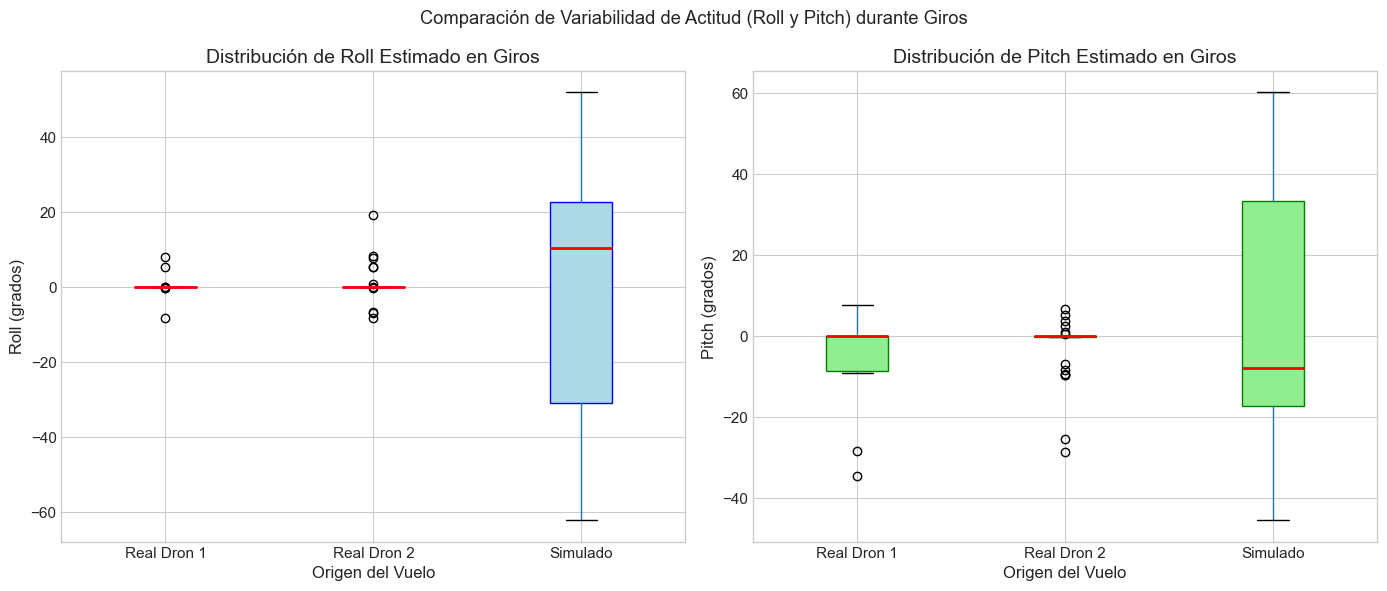

In [12]:
# Combinamos los datos en un solo DataFrame para graficar con facilidad
df_d1_proc['source'] = 'Real Dron 1'
df_d2_proc['source'] = 'Real Dron 2'
df_sim_all['source'] = 'Simulado'

cols_to_keep = ['est_roll', 'est_pitch', 'yaw_rate_deg', 'maneuver', 'source']
df_combined = pd.concat([
    df_d1_proc[cols_to_keep],
    df_d2_proc[cols_to_keep],
    df_sim_all[cols_to_keep]
], ignore_index=True)

# Filtrar para fases de giro
df_turns = df_combined[df_combined['maneuver'] == 'Giro']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot de Roll
df_turns.boxplot(column='est_roll', by='source', ax=ax1, grid=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='blue'),
                 medianprops=dict(color='red', linewidth=2))
ax1.set_title('Distribución de Roll Estimado en Giros')
ax1.set_ylabel('Roll (grados)')
ax1.set_xlabel('Origen del Vuelo')

# Boxplot de Pitch
df_turns.boxplot(column='est_pitch', by='source', ax=ax2, grid=True, patch_artist=True,
                 boxprops=dict(facecolor='lightgreen', color='green'),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_title('Distribución de Pitch Estimado en Giros')
ax2.set_ylabel('Pitch (grados)')
ax2.set_xlabel('Origen del Vuelo')

plt.suptitle('Comparación de Variabilidad de Actitud (Roll y Pitch) durante Giros')
plt.tight_layout()
plt.show()


## 9. Conclusiones y Discusión de Resultados

Al analizar y contrastar la telemetría real contra la simulada durante las maniobras de cambio de dirección, observamos diferencias dinámicas fundamentales:

1. **Variabilidad General (Varianza):**
   - La prueba de **Levene** rechaza de manera categórica ($p < 0.001$) la hipótesis nula de varianza igual. Esto demuestra formalmente que la variabilidad de vuelo no es la misma en la realidad y en la simulación.
   - En **vuelo simulado**, la varianza de roll y pitch es excepcionalmente alta durante los giros (llegando a extremos de $-61^\circ$ a $50^\circ$ de inclinación). Esto se debe a que la simulación de AirSim tiene un controlador de actitud sumamente agresivo (alta ganancia de control) que busca completar la maniobra rectangular o en cruz a velocidades objetivo de forma casi instantánea, provocando inclinaciones extremas para generar las fuerzas centrípetas requeridas.
   - En **vuelo real**, el dron está limitado físicamente (el sistema de control de estabilidad de DJI suele bloquear inclinaciones superiores a $30^\circ - 35^\circ$ en modos estándar). Por lo tanto, la variabilidad está mucho más controlada y acotada (roll de $-8^\circ$ a $8^\circ$).

2. **Efectos Climáticos y Perturbaciones:**
   - En los segmentos de **recta**, la simulación tiene una varianza de actitud y rumbo extremadamente baja (casi determinista e ideal, varianza cercana a $0$).
   - Por el contrario, los drones reales presentan una variabilidad constante en los tramos rectos (variación continua en roll y pitch de un par de grados y ruido de heading). Esto es la firma directa de la **dinámica atmosférica (viento, ráfagas)** y del **ruido de los sensores de a bordo (GPS e IMU)**, obligando al piloto automático a realizar micro-correcciones continuas para mantener la línea de vuelo.

3. **Conclusión Final:**
   Aunque la simulación modela la respuesta inercial elemental (el dron debe inclinarse para cambiar de rumbo), lo hace de forma idealizada y con parámetros de aceleración más agresivos que los del vuelo real instrumentado. El modelo simulado de AirSim carece del amortiguamiento de actitud real, y no captura de manera natural el ruido y las ráfagas meteorológicas del entorno alpino en el que se levantó la telemetría consolidada, a menos que se configure explícitamente un perfil estocástico de viento.
